# Write a functional environment

Runnable locally on CPU or on a Cloud TPU VM.

- Implement reset and step as pure functions with explicit state.
- Distinguish termination, time-limit truncation and an absorbing finished state.
- Check transitions independently before using rewards to train a policy.

A learner agent reaches a goal, but its reported reward keeps increasing afterward. Is the policy improving, or is the environment paying it repeatedly? Before training anything, we will build a small environment whose entire transition table can be checked. You will leave with explicit rules for starting, moving, ending and resetting an episode.

## The idea

A functional environment receives state and action and returns the next state, reward and termination information. Define exactly which transition earns reward and what later terminal padding means. This keeps rollouts and return calculations consistent.

## Reward belongs to a transition

Suppose entering the goal earns one reward. The transition into the goal counts once. Later padded steps in the terminal state should not repeatedly earn the same reward unless that is explicitly the task's intended reward rule.

Draw separate arrows for an ordinary move, a goal-reaching move and terminal padding. A timeout is another condition whose treatment must be specified; it is not automatically the same learning signal as reaching a terminal goal.

The reward trace shows one event followed by absorbing padding. Read the event's time index against the transition convention. Then test actions after termination to ensure padding does not introduce extra rewards or unintended state changes.

### Pause and reason

Why can checking only the final state miss a reward bug?

<details><summary>Compare your reasoning</summary>

A rollout can end in the correct goal while counting its reward repeatedly during padding. Check transition rewards and accumulated return as well as final state.

</details>

## State contains what the next transition needs

Our state holds position, elapsed steps and a done flag. Observation is position: enough for the stationary policy used here, but not the full finite-horizon decision state. A policy that needs to reason about time remaining should also observe elapsed time. Carrying elapsed time in environment state prevents a time limit from depending on a hidden Python counter. NamedTuple fields are JAX pytree leaves, so the same function can run directly, under jit, or under vmap.

## Walk through the reward before naming the return

Start at position $1$, then move right twice. The first action reaches position $2$ and earns $-0.01$. The second reaches the goal and earns $1$. Total reward is $0.99$. Starting at position $0$ instead needs one extra move and earns $0.98$. Return means the sum of rewards in this lesson; we do not discount future rewards. Averaging over our two equally likely starts gives the always-right policy return $0.985$.

$$
G=\sum_{t=0}^{H-1}r_t,\qquad H=8
$$

## Ending is an event; finished is a state

Terminated marks the transition that reaches the goal. Truncated marks an active transition that reaches the time limit without reaching the goal. A simultaneous goal and time limit counts as termination here. The done flag remains true afterward, but subsequent padded transitions emit neither event and pay zero. This lets us collect a fixed-size array without inventing extra episodes. We never auto-reset inside step: the returned position is the final observation, not a replacement start.

## A timeout does not always mean a zero future value

Here the task itself asks for the return during a fixed budget of actions, so truncation ends our finite-horizon objective and its future value is zero. In a continuing task interrupted only by a collection limit, the final observation can still have future value. A bootstrapped target would then mask true termination, not every timeout. For reward $-0.01$, discount $0.9$ and estimated next value $2$, that continuing target is $1.79$; replacing it with $-0.01$ changes the learning problem.

$$
y=r+\gamma(1-\mathbb{1}_{\mathrm{terminated}})V(s_{\mathrm{next}})
$$

## Make the contract small enough to test

The compiled transition assumes a binary integer action, positive horizon, and states produced by reset or step. We test those rules outside the hot loop rather than performing Python assertions on traced values. Randomness enters reset through a supplied key. Reusing that key deliberately reproduces a start; independent starts require split keys. The transition itself is deterministic. This is a teaching task, not evidence of skill on a realistic control benchmark.

## Define state and the transition

Create main.py with this block. Run python3 main.py in the course CPU environment.

In [1]:
# Step 1: Define state and the transition
"""Finite-horizon tabular policy training. CPU teaching environment, not a benchmark."""
# Import functools (partial) for this computation.
from functools import partial
from typing import NamedTuple
import jax
import jax.numpy as jnp
import numpy as np


# Define `State` module / container with explicit state and forward pass:
class State(NamedTuple):
    # Execute `position: jax.Array`
    position: jax.Array
    # Execute `elapsed: jax.Array`
    elapsed: jax.Array
    # Execute `done: jax.Array`
    done: jax.Array


# Function `reset(key)` implementing this stage's computation:
def reset(key):
    """Start uniformly at position 0 or 1; goal is position 3."""
    # Return `State(jax.random.randint(key, (), 0, 2), jnp.int32(0), jnp.bool_(False))` to the caller.
    return State(jax.random.randint(key, (), 0, 2), jnp.int32(0), jnp.bool_(False))


# Function `step(state, action, horizon)` implementing this stage's computation:
def step(state, action, horizon=8):
    """Action 0: left, 1: right. Caller supplies binary action and positive horizon.

    Returns next state, reward, termination event, truncation event. Finished
    states absorb without more rewards/events. No implicit reset or lost final observation.
    """
    # Compute `active` from `~state.done`
    active = ~state.done
    # Combine or mask array elements to form `proposed`.
    proposed = jnp.clip(state.position + 2 * action - 1, 0, 3)
    # Combine or mask array elements to form `position`.
    position = jnp.where(active, proposed, state.position)
    # Compute `elapsed` from `state.elapsed + active.astype(jnp.int32)`
    elapsed = state.elapsed + active.astype(jnp.int32)
    # Compute `terminated` from `active & (position == 3)`
    terminated = active & (position == 3)
    # Compute `truncated` from `active & ~terminated & (elapsed >= horizon)`
    truncated = active & ~terminated & (elapsed >= horizon)
    # Combine or mask array elements to form `reward`.
    reward = jnp.where(active, jnp.where(terminated, 1., -.01), 0.)
    # Return `(State(position, elapsed, state.done | terminated | truncated), reward, terminated, truncated)` to the caller.
    return State(position, elapsed, state.done | terminated | truncated), reward, terminated, truncated

The function returns all information needed by the next call. No hidden counter or reset changes the episode.

## Check a complete episode

Append this block to main.py. Run python3 main.py in the course CPU environment.

In [2]:
# Step 2 — Check a complete episode: The known two-action path produces one terminal reward and then...
s = State(jnp.int32(1), jnp.int32(0), jnp.bool_(False))
# Compute `positions, rewards` from `[int(s.position)], []`
positions, rewards = [int(s.position)], []
# Iterate over `action` to step through the computation:
for action in [1, 1, 0, 0]:
    # Run `step` to compute `(s, reward, terminated, truncated)`.
    s, reward, terminated, truncated = step(s, jnp.int32(action))
    # Append the current step result to `positions`.
    # Append the current step result to `positions`.
    positions.append(int(s.position))
    rewards.append(float(reward))
# Assert invariant `positions == [1, 2, 3, 3, 3]` holds
assert positions == [1, 2, 3, 3, 3]
# Assert that `jnp.allclose(jnp.array(rewards), jnp.array([-.01, 1., 0., 0.]))`.
assert jnp.allclose(jnp.array(rewards), jnp.array([-.01, 1., 0., 0.]))
# Assert invariant `int(s.elapsed) == 2` holds
assert int(s.elapsed) == 2
# Print the observed values to compare against the expected result.
print('positions:', positions, 'rewards:', rewards)

positions: [1, 2, 3, 3, 3] rewards: [-0.009999999776482582, 1.0, 0.0, 0.0]


The known two-action path produces one terminal reward and then zero padding.

## Step 3: Verify invariants on the completed state

Run the final shape and numerical assertions to confirm the state built in Steps 1 and 2.

In [3]:
assert jnp.allclose(jnp.array(rewards), jnp.array([-.01, 1., 0., 0.]))
assert int(s.elapsed) == 2

Checking these invariants confirms the computation is ready for the full worked experiment.

## Run the example

In [4]:
# Complete runnable example (rl-01)
"""Finite-horizon tabular policy training. CPU teaching environment, not a benchmark."""
# Import functools (partial) for this computation.
from functools import partial
from typing import NamedTuple
import jax
import jax.numpy as jnp
import numpy as np


# Define `State` module / container with explicit state and forward pass:
class State(NamedTuple):
    # Execute `position: jax.Array`
    position: jax.Array
    # Execute `elapsed: jax.Array`
    elapsed: jax.Array
    # Execute `done: jax.Array`
    done: jax.Array


# Function `reset(key)` implementing this stage's computation:
def reset(key):
    """Start uniformly at position 0 or 1; goal is position 3."""
    # Return `State(jax.random.randint(key, (), 0, 2), jnp.int32(0), jnp.bool_(False))` to the caller.
    return State(jax.random.randint(key, (), 0, 2), jnp.int32(0), jnp.bool_(False))


# Function `step(state, action, horizon)` implementing this stage's computation:
def step(state, action, horizon=8):
    """Action 0: left, 1: right. Caller supplies binary action and positive horizon.

    Returns next state, reward, termination event, truncation event. Finished
    states absorb without more rewards/events. No implicit reset or lost final observation.
    """
    # Compute `active` from `~state.done`
    active = ~state.done
    # Combine or mask array elements to form `proposed`.
    proposed = jnp.clip(state.position + 2 * action - 1, 0, 3)
    # Combine or mask array elements to form `position`.
    position = jnp.where(active, proposed, state.position)
    # Compute `elapsed` from `state.elapsed + active.astype(jnp.int32)`
    elapsed = state.elapsed + active.astype(jnp.int32)
    # Compute `terminated` from `active & (position == 3)`
    terminated = active & (position == 3)
    # Compute `truncated` from `active & ~terminated & (elapsed >= horizon)`
    truncated = active & ~terminated & (elapsed >= horizon)
    # Combine or mask array elements to form `reward`.
    reward = jnp.where(active, jnp.where(terminated, 1., -.01), 0.)
    # Return `(State(position, elapsed, state.done | terminated | truncated), reward, terminated, truncated)` to the caller.
    return State(position, elapsed, state.done | terminated | truncated), reward, terminated, truncated

# Step 2 — Check a complete episode: The known two-action path produces one terminal reward and then...
s = State(jnp.int32(1), jnp.int32(0), jnp.bool_(False))
# Compute `positions, rewards` from `[int(s.position)], []`
positions, rewards = [int(s.position)], []
# Iterate over `action` to step through the computation:
for action in [1, 1, 0, 0]:
    # Run `step` to compute `(s, reward, terminated, truncated)`.
    s, reward, terminated, truncated = step(s, jnp.int32(action))
    # Append the current step result to `positions`.
    # Append the current step result to `positions`.
    positions.append(int(s.position))
    rewards.append(float(reward))
# Assert invariant `positions == [1, 2, 3, 3, 3]` holds
assert positions == [1, 2, 3, 3, 3]
# Assert that `jnp.allclose(jnp.array(rewards), jnp.array([-.01, 1., 0., 0.]))`.
assert jnp.allclose(jnp.array(rewards), jnp.array([-.01, 1., 0., 0.]))
# Assert invariant `int(s.elapsed) == 2` holds
assert int(s.elapsed) == 2
# Print the observed values to compare against the expected result.
print('positions:', positions, 'rewards:', rewards)

positions: [1, 2, 3, 3, 3] rewards: [-0.009999999776482582, 1.0, 0.0, 0.0]


Expected: Positions are $(1,2,3,3,3)$. Rewards are $(-0.01,1,0,0)$; elapsed time stops at $2$.

## One goal reward, then absorbing padding

Predict: Will the reward stay at one after the goal?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: One goal reward, then absorbing padding
# Combine or mask array elements to form `visual_data`.
visual_data = {'kind':'line','x':[1,2,3,4],'xlabel':'transition index','ylabel':'reward per transition','series':[{'label':'right, right, padded, padded','y':rewards}]}

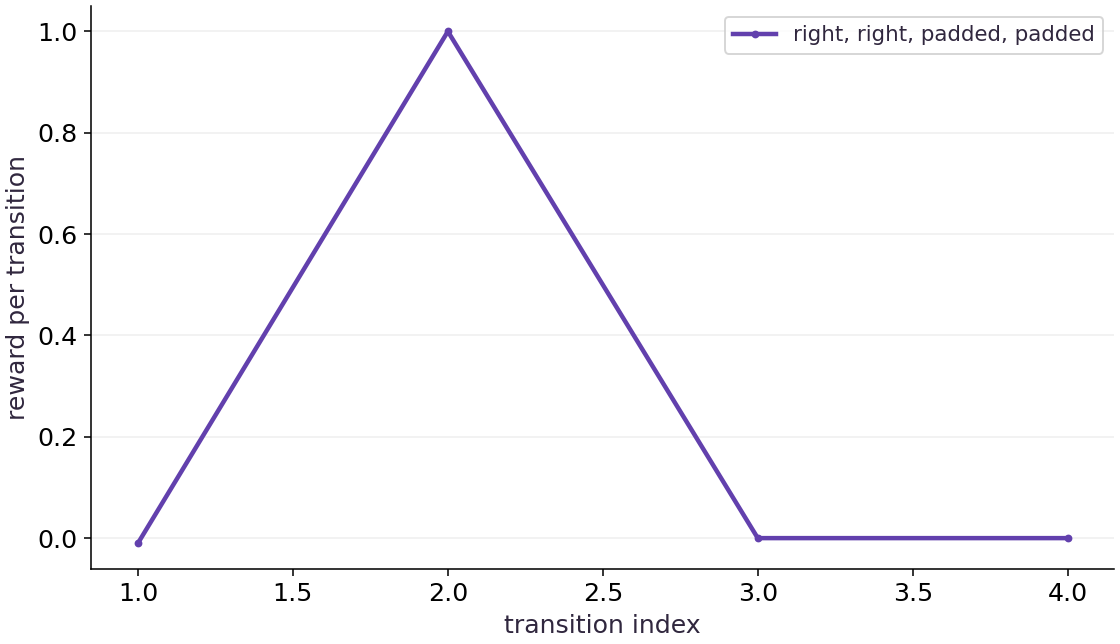

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis counts transitions, starting with the first action. The vertical axis is reward for that individual transition, not accumulated return. Moving right twice from position $1$ produces $-0.01$ followed by $1$. The final two points sit at zero because the episode has already ended.

### Connect it to the computation

The positions printed by the program are $(1,2,3,3,3)$. The sharp reward peak occurs only when entering the goal. Summing the four plotted rewards gives $0.99$, exactly the two-action return. A flat tail at $1$ would expose repeated terminal rewards; this zero tail demonstrates the absorbing-state contract, not learning.

## A goal at the deadline

Predict: Which event wins if the final permitted action reaches the goal?

In [7]:
# Experiment — A goal at the deadline: The goal transition defines a completed task, so the two flags...
s = State(jnp.int32(2), jnp.int32(1), jnp.bool_(False))
# Run `step` to compute `(s, r, term, trunc)`.
s, r, term, trunc = step(s, jnp.int32(1), horizon=2)
# Assert invariant `bool(term) and not bool(trunc) and float(r) == 1.` holds
assert bool(term) and not bool(trunc) and float(r) == 1.
# Print the observed values to compare against the expected result.
print('deadline goal:', bool(term), bool(trunc))

deadline goal: True False


Expected: Termination is true; truncation is false.

The goal transition defines a completed task, so the two flags remain mutually exclusive.

## The same key is the same start

Predict: Will resetting twice with one key produce two independent trials?

In [8]:
# Experiment — The same key is the same start: This verifies the randomness contract, not a guarantee that...
# Create or split explicit PRNG key(s) (`key`) for reproducible randomness.
key = jax.random.key(7)
# Compute `a, b` from `reset(key), reset(key)`
a, b = reset(key), reset(key)
# Assert invariant `int(a.position) == int(b.position)` holds
assert int(a.position) == int(b.position)
# Create or split explicit PRNG key(s) (`starts`) for reproducible randomness.
starts = jax.vmap(reset)(jax.random.split(key, 1000)).position
# Assert invariant `0.4 < float(starts.mean()) < 0.6` holds
assert 0.4 < float(starts.mean()) < 0.6
# Print the observed values to compare against the expected result.
print('fraction starting at one:', float(starts.mean()))

fraction starting at one: 0.5020000338554382


Expected: Replay is exact; a split-key batch contains both starts.

This verifies the randomness contract, not a guarantee that every tiny batch is balanced.

## Your exercise

Begin at position $0$, choose left for three actions with horizon $3$, and then attempt one more action. Verify the event flags, total reward and absorbing state.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `State(...)` — Call `State` with your updated parameters or inputs from this lesson's workspace.
- `jnp.int32(...)` — Call `jnp.int32` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Compute `total` from `0.`
2. Iterate over `i` to step through the computation:
3. Run `step` to compute `(s, r, term, trunc)`.
4. Accumulate the next contribution into `total`.
5. Assert invariant `not bool(term) and bool(trunc) == (i == 2)` holds

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Begin at position 0, choose left for three actions with horizon 3, and...
s = State(...)  # TODO: compute s
# Compute `total` from `0.`
total = ...  # TODO: compute total
# Iterate over `i` to step through the computation:
for i in range(3):
    # Run `step` to compute `(s, r, term, trunc)`.
    s, r, term, trunc = step(...)  # TODO: compute s, r, term, trunc
    # Accumulate the next contribution into `total`.
    total += float(r)
    # Assert invariant `not bool(term) and bool(trunc) == (i == 2)` holds
    assert not bool(term)  # TODO: complete assertion check
# Assert that `abs(total + .03) < 1e-6`.
assert abs(total + .03)  # TODO: complete assertion check
# Run `step` to compute `(s2, r, term, trunc)`.
s2, r, term, trunc = step(...)  # TODO: compute s2, r, term, trunc
# Assert invariant `int(s2.position) == 0 and int(s2.elapsed) == 3 and float(r) == 0.` holds
assert int(s2.position)  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Begin at position 0, choose left for three actions with horizon 3, and...
# s = State(...)  # TODO: compute s
# Compute `total` from `0.`
# total = ...  # TODO: compute total
# Iterate over `i` to step through the computation:
# for i in range(3):
    # Run `step` to compute `(s, r, term, trunc)`.
#     s, r, term, trunc = step(...)  # TODO: compute s, r, term, trunc
    # Accumulate the next contribution into `total`.
#     total += float(r)
    # Assert invariant `not bool(term) and bool(trunc) == (i == 2)` holds
#     assert not bool(term)  # TODO: complete assertion check
# Assert that `abs(total + .03) < 1e-6`.
# assert abs(total + .03)  # TODO: complete assertion check
# Run `step` to compute `(s2, r, term, trunc)`.
# s2, r, term, trunc = step(...)  # TODO: compute s2, r, term, trunc
# Assert invariant `int(s2.position) == 0 and int(s2.elapsed) == 3 and float(r) == 0.` holds
# assert int(s2.position)  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Begin at position 0, choose left for three actions with horizon 3, and...
s = State(jnp.int32(0), jnp.int32(0), jnp.bool_(False))
# Compute `total` from `0.`
total = 0.
# Iterate over `i` to step through the computation:
for i in range(3):
    # Run `step` to compute `(s, r, term, trunc)`.
    s, r, term, trunc = step(s, jnp.int32(0), 3)
    # Accumulate the next contribution into `total`.
    total += float(r)
    # Assert invariant `not bool(term) and bool(trunc) == (i == 2)` holds
    assert not bool(term) and bool(trunc) == (i == 2)
# Assert that `abs(total + .03) < 1e-6`.
assert abs(total + .03) < 1e-6
# Run `step` to compute `(s2, r, term, trunc)`.
s2, r, term, trunc = step(s, jnp.int32(1), 3)
# Assert invariant `int(s2.position) == 0 and int(s2.elapsed) == 3 and float(r) == 0.` holds
assert int(s2.position) == 0 and int(s2.elapsed) == 3 and float(r) == 0.

## Separate the two target meanings · Transfer / diagnosis

Compute the continuing-task bootstrap target for a timeout and a true terminal transition when $r=-0.01$, $\gamma=0.9$ and $V=2$. Compare with our finite-horizon objective.

Hint: Use the termination flag for the continuing task. The finite-horizon task assigns zero value after its own deadline.

### How to write: Separate the two target meanings — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `meanings(...)` — Call `meanings` with your updated parameters or inputs from this lesson's workspace.
- `abs(...)` — Call `abs` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Compute `continuing_timeout` from `r + gamma * value`
2. Compute `terminal` from `r`
3. Compute `finite_horizon_timeout` from `r`
4. Assert that `abs(continuing_timeout - 1.79) < 1e-7`.
5. Assert invariant `terminal == finite_horizon_timeout == -.01` holds

**Starter code scaffold (fill in the TODOs):**

```python
# Separate the two target meanings (Transfer / diagnosis): The arithmetic exposes a modeling choice.
r, gamma, value = ...  # TODO: compute r, gamma, value
# Compute `continuing_timeout` from `r + gamma * value`
continuing_timeout = ...  # TODO: compute continuing_timeout
# Compute `terminal` from `r`
terminal = ...  # TODO: compute terminal
# Compute `finite_horizon_timeout` from `r`
finite_horizon_timeout = ...  # TODO: compute finite_horizon_timeout
# Assert that `abs(continuing_timeout - 1.79) < 1e-7`.
assert abs(continuing_timeout - 1.79)  # TODO: complete assertion check
# Assert invariant `terminal == finite_horizon_timeout == -.01` holds
assert terminal  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Separate the two target meanings (Transfer / diagnosis): The arithmetic exposes a modeling choice.
# r, gamma, value = ...  # TODO: compute r, gamma, value
# Compute `continuing_timeout` from `r + gamma * value`
# continuing_timeout = ...  # TODO: compute continuing_timeout
# Compute `terminal` from `r`
# terminal = ...  # TODO: compute terminal
# Compute `finite_horizon_timeout` from `r`
# finite_horizon_timeout = ...  # TODO: compute finite_horizon_timeout
# Assert that `abs(continuing_timeout - 1.79) < 1e-7`.
# assert abs(continuing_timeout - 1.79)  # TODO: complete assertion check
# Assert invariant `terminal == finite_horizon_timeout == -.01` holds
# assert terminal  # TODO: complete assertion check

## Reference reasoning

The arithmetic exposes a modeling choice. Copying a done mask from a different task can silently change the objective.

In [12]:
# Separate the two target meanings (Transfer / diagnosis): The arithmetic exposes a modeling choice.
r, gamma, value = -.01, .9, 2.
# Compute `continuing_timeout` from `r + gamma * value`
continuing_timeout = r + gamma * value
# Compute `terminal` from `r`
terminal = r
# Compute `finite_horizon_timeout` from `r`
finite_horizon_timeout = r
# Assert that `abs(continuing_timeout - 1.79) < 1e-7`.
assert abs(continuing_timeout - 1.79) < 1e-7
# Assert invariant `terminal == finite_horizon_timeout == -.01` holds
assert terminal == finite_horizon_timeout == -.01

## Enumerate all one-step moves · Transfer / diagnosis

Check both actions at every unfinished position with a Python reference, then compare the jitted function.

Hint: Use ordinary min and max for the independent reference.

### How to write: Enumerate all one-step moves — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jax.jit(fn) / @jax.jit` — Traces `fn` with abstract shapes and compiles a fused XLA executable cached by input shape and dtype.

**Step-by-step implementation plan:**
1. Wrap with `jax.jit` (`compiled`) so XLA traces and compiles the function.
2. Iterate over `position` to step through the computation:
3. Loop over `action` in `[0, 1]`:
4. Run `State` to compute `s`.
5. Run `compiled` to compute `(nxt, reward, term, trunc)`.

**Starter code scaffold (fill in the TODOs):**

```python
# Enumerate all one-step moves (Transfer / diagnosis): Enumeration checks boundary behavior separately from the...
# Wrap with `jax.jit` (`compiled`) so XLA traces and compiles the function.
compiled = jax.jit(...)  # TODO: compute compiled
# Iterate over `position` to step through the computation:
for position in range(3):
    # Loop over `action` in `[0, 1]`:
    for action in [0, 1]:
        # Run `State` to compute `s`.
        s = State(...)  # TODO: compute s
        # Run `compiled` to compute `(nxt, reward, term, trunc)`.
        nxt, reward, term, trunc = compiled(...)  # TODO: compute nxt, reward, term, trunc
        # Run `min` to compute `expected`.
        expected = min(...)  # TODO: compute expected
        # Assert invariant `int(nxt.position) == expected` holds
        assert int(nxt.position)  # TODO: complete assertion check
        # Assert invariant `bool(term) == (expected == 3)` holds
        assert bool(term)  # TODO: complete assertion check
        # Assert that `abs(float(reward) - (1. if expected == 3 else -.01)) < 1e-6`.
        assert abs(float(reward) - (1. if expected  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Enumerate all one-step moves (Transfer / diagnosis): Enumeration checks boundary behavior separately from the...
# Wrap with `jax.jit` (`compiled`) so XLA traces and compiles the function.
# compiled = jax.jit(...)  # TODO: compute compiled
# Iterate over `position` to step through the computation:
# for position in range(3):
    # Loop over `action` in `[0, 1]`:
#     for action in [0, 1]:
        # Run `State` to compute `s`.
#         s = State(...)  # TODO: compute s
        # Run `compiled` to compute `(nxt, reward, term, trunc)`.
#         nxt, reward, term, trunc = compiled(...)  # TODO: compute nxt, reward, term, trunc
        # Run `min` to compute `expected`.
#         expected = min(...)  # TODO: compute expected
        # Assert invariant `int(nxt.position) == expected` holds
#         assert int(nxt.position)  # TODO: complete assertion check
        # Assert invariant `bool(term) == (expected == 3)` holds
#         assert bool(term)  # TODO: complete assertion check
        # Assert that `abs(float(reward) - (1. if expected == 3 else -.01)) < 1e-6`.
#         assert abs(float(reward) - (1. if expected  # TODO: complete assertion check

## Reference reasoning

Enumeration checks boundary behavior separately from the vectorized implementation.

In [14]:
# Enumerate all one-step moves (Transfer / diagnosis): Enumeration checks boundary behavior separately from the...
# Wrap with `jax.jit` (`compiled`) so XLA traces and compiles the function.
compiled = jax.jit(step)
# Iterate over `position` to step through the computation:
for position in range(3):
    # Loop over `action` in `[0, 1]`:
    for action in [0, 1]:
        # Run `State` to compute `s`.
        s = State(jnp.int32(position), jnp.int32(0), jnp.bool_(False))
        # Run `compiled` to compute `(nxt, reward, term, trunc)`.
        nxt, reward, term, trunc = compiled(s, jnp.int32(action))
        # Run `min` to compute `expected`.
        expected = min(3, max(0, position + (1 if action else -1)))
        # Assert invariant `int(nxt.position) == expected` holds
        assert int(nxt.position) == expected
        # Assert invariant `bool(term) == (expected == 3)` holds
        assert bool(term) == (expected == 3)
        # Assert that `abs(float(reward) - (1. if expected == 3 else -.01)) < 1e-6`.
        assert abs(float(reward) - (1. if expected == 3 else -.01)) < 1e-6

## Checkpoint

What should step emit when called on a finished state?

1. Another goal reward because the agent is still at the goal
2. A new random start and its first reward
3. The unchanged state, zero reward and no new ending event

## Diagnose

If return exceeds the always-right value, inspect rewards after the first ending event. If a trajectory jumps from the goal to a start, look for auto-reset before storing the final observation. If all starts match, inspect whether keys were split before batching.

## Evidence

Keep independent transition enumeration, reward/terminal checks and the absorbing-state diagnosis. Explain the state and observation contract.

## Carry forward

- Environment state, observation and policy parameters are different objects.
- Explicit ending contracts make fixed-shape rollouts safe to interpret.

## Primary references

- [JAX: explicit pseudorandom keys](https://docs.jax.dev/en/latest/random-numbers.html)
- [JAX scan: fixed-shape carry](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html)
- [Schulman et al.: Proximal Policy Optimization Algorithms](https://arxiv.org/abs/1707.06347)
- [Gymnasium: termination and truncation](https://gymnasium.farama.org/tutorials/gymnasium_basics/handling_time_limits/)